# Model Evaluation

This notebook evaluates the performance of the machine learning models developed in Notebook 04.

The objectives are to:

- Load the saved machine learning models.
- Evaluate predictive performance on the testing dataset.
- Compare Logistic Regression, Decision Tree, and Random Forest.
- Generate evaluation metrics and visualizations.
- Interpret model performance.

# Imports

In [1]:
from pathlib import Path
import joblib

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define Project Paths

In [5]:
ROOT_DIR = Path.cwd().parent

PROCESSED_DIR = ROOT_DIR / "data" / "processed"

master_df = pd.read_csv(
    PROCESSED_DIR / "master_dataset.csv"
)

print(master_df.shape)
display(master_df.head())

(5432, 63)


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hospital_type,hospital_ownership,...,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,9.4,10.2,18.4,13.5,13.0,10.1,18.0,20.1,4.8,16.0
1,10005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,8.9,14.1,21.2,12.9,NaN,NaN,17.1,19.8,4.2,13.9
2,10006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,8.7,12.5,19.6,12.4,12.5,10.6,19.1,19.5,5.1,15.7
3,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,11.2,13.4,25.4,NaN,NaN,NaN,18.6,20.9,NaN,16.5
4,10011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,9.1,14.4,20.1,12.8,13.2,11.9,18.2,20.9,NaN,16.2


# Load the Master Dataset

In [6]:
ROOT_DIR = Path.cwd().parent

PROCESSED_DIR = ROOT_DIR / "data" / "processed"

master_df = pd.read_csv(
    PROCESSED_DIR / "master_dataset.csv"
)

print(master_df.shape)
display(master_df.head())

(5432, 63)


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hospital_type,hospital_ownership,...,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,9.4,10.2,18.4,13.5,13.0,10.1,18.0,20.1,4.8,16.0
1,10005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,8.9,14.1,21.2,12.9,NaN,NaN,17.1,19.8,4.2,13.9
2,10006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,8.7,12.5,19.6,12.4,12.5,10.6,19.1,19.5,5.1,15.7
3,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,11.2,13.4,25.4,NaN,NaN,NaN,18.6,20.9,NaN,16.5
4,10011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,9.1,14.4,20.1,12.8,13.2,11.9,18.2,20.9,NaN,16.2


# Prepare Modeling Dataset

In [7]:
model_df = master_df.dropna(
    subset=["hospital_overall_rating"]
).copy()

model_df["hospital_overall_rating"] = (
    model_df["hospital_overall_rating"].astype(int)
)

# Build Feature Matrix

In [8]:
# Keep only hospitals with a CMS Overall Rating
model_df = master_df.dropna(
    subset=["hospital_overall_rating"]
).copy()

# Convert the target to integer class labels
model_df["hospital_overall_rating"] = (
    model_df["hospital_overall_rating"].astype(int)
)

print(model_df.shape)

display(
    model_df["hospital_overall_rating"]
    .value_counts()
    .sort_index()
)

(3182, 63)


hospital_overall_rating
1    199
2    662
3    987
4    950
5    384
Name: count, dtype: int64

In [11]:
target = "hospital_overall_rating"

drop_columns = [
    # identifiers
    "facility_id",
    "facility_name",
    "address",
    "telephone_number",
    "zip_code",

    # target
    "hospital_overall_rating",

    # footnotes
    "hospital_overall_rating_footnote",
    "mort_group_footnote",
    "safety_group_footnote",
    "readm_group_footnote",
    "pt_exp_group_footnote",
    "te_group_footnote",

    # CMS summary variables
    "mort_group_measure_count",
    "count_of_facility_mort_measures",
    "count_of_mort_measures_better",
    "count_of_mort_measures_no_different",
    "count_of_mort_measures_worse",

    "safety_group_measure_count",
    "count_of_facility_safety_measures",
    "count_of_safety_measures_better",
    "count_of_safety_measures_no_different",
    "count_of_safety_measures_worse",

    "readm_group_measure_count",
    "count_of_facility_readm_measures",
    "count_of_readm_measures_better",
    "count_of_readm_measures_no_different",
    "count_of_readm_measures_worse",

    "pt_exp_group_measure_count",
    "count_of_facility_pt_exp_measures",

    "te_group_measure_count",
    "count_of_facility_te_measures",
]

X = model_df.drop(columns=drop_columns)
y = model_df[target].astype(int)

print("Predictors:", X.shape)
print("Target:", y.shape)

Predictors: (3182, 32)
Target: (3182,)


# Identify Feature Types

In [12]:
categorical_features = (
    X.select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

numeric_features = (
    X.select_dtypes(include=["number"])
    .columns
    .tolist()
)

print(f"Categorical features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nNumeric features ({len(numeric_features)}):")
print(numeric_features)

Categorical features (7):
['city_town', 'state', 'county_parish', 'hospital_type', 'hospital_ownership', 'emergency_services', 'meets_criteria_for_birthing_friendly_designation']

Numeric features (25):
['cleanliness_star', 'nurse_comm_star', 'doctor_comm_star', 'medicine_comm_star', 'discharge_info_star', 'quietness_star', 'recommend_hospital_star', 'clabsi_sir', 'cauti_sir', 'colon_ssi_sir', 'hysterectomy_ssi_sir', 'mrsa_sir', 'cdiff_sir', 'heart_attack_mortality', 'cabg_mortality', 'copd_mortality', 'heart_failure_mortality', 'pneumonia_mortality', 'stroke_mortality', 'heart_attack_readmit', 'cabg_readmit', 'copd_readmit', 'heart_failure_readmit', 'hip_knee_readmit', 'pneumonia_readmit']


# Train, Test, Split Data

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training predictors:", X_train.shape)
print("Testing predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training predictors: (2545, 32)
Testing predictors: (637, 32)
Training target: (2545,)
Testing target: (637,)


# Load Saved Models

In [14]:
logistic_model = joblib.load(
    MODELS_DIR / "logistic_regression.pkl"
)

decision_tree_model = joblib.load(
    MODELS_DIR / "decision_tree.pkl"
)

random_forest_model = joblib.load(
    MODELS_DIR / "random_forest.pkl"
)

# Generate Predictions

In [15]:
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

# Accuracy Comparison

In [16]:
results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
        ],
        "Accuracy": [
            accuracy_score(y_test, logistic_pred),
            accuracy_score(y_test, decision_tree_pred),
            accuracy_score(y_test, random_forest_pred),
        ],
    }
)

results.sort_values(
    "Accuracy",
    ascending=False,
)

,Model,Accuracy
0,Logistic Regression,0.536892
1,Decision Tree,0.450549
2,Random Forest,0.417582


# Classification Reports

In [17]:
print("Logistic Regression")
print(classification_report(y_test, logistic_pred))

Logistic Regression
              precision    recall  f1-score   support

           1       0.40      0.62      0.49        40
           2       0.55      0.53      0.54       132
           3       0.55      0.48      0.51       198
           4       0.56      0.53      0.54       190
           5       0.54      0.66      0.59        77

    accuracy                           0.54       637
   macro avg       0.52      0.57      0.54       637
weighted avg       0.54      0.54      0.54       637



In [18]:
print("Decision Tree")
print(classification_report(y_test, decision_tree_pred))

Decision Tree
              precision    recall  f1-score   support

           1       0.26      0.20      0.23        40
           2       0.43      0.42      0.42       132
           3       0.45      0.45      0.45       198
           4       0.47      0.54      0.50       190
           5       0.53      0.43      0.47        77

    accuracy                           0.45       637
   macro avg       0.43      0.41      0.41       637
weighted avg       0.45      0.45      0.45       637



In [19]:
print("Random Forest")
print(classification_report(y_test, random_forest_pred))

Random Forest
              precision    recall  f1-score   support

           1       0.32      0.75      0.45        40
           2       0.41      0.42      0.42       132
           3       0.56      0.30      0.39       198
           4       0.47      0.30      0.37       190
           5       0.35      0.83      0.50        77

    accuracy                           0.42       637
   macro avg       0.42      0.52      0.42       637
weighted avg       0.46      0.42      0.41       637



# Confusion Matrix for all 3 Models

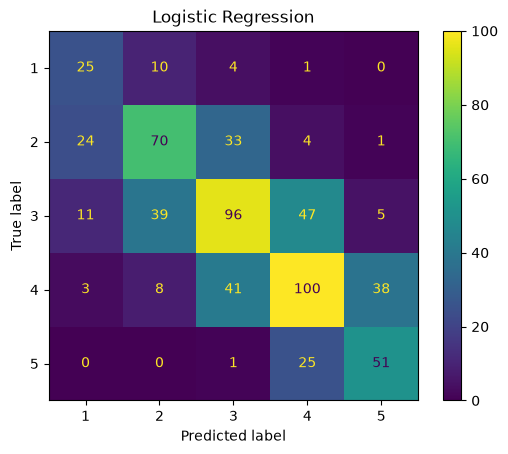

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
)

plt.title("Logistic Regression")
plt.show()

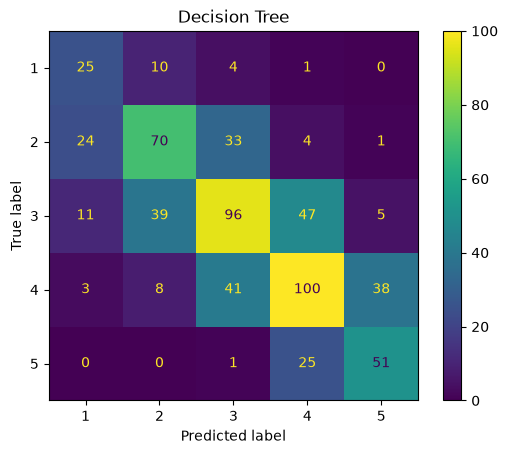

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
)

plt.title("Decision Tree")
plt.show()

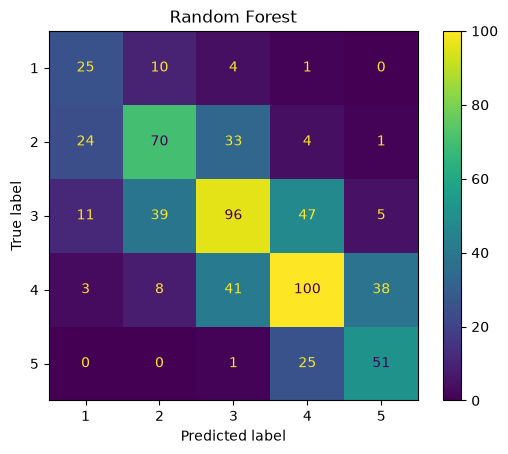

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
)

plt.title("Random Forest")
plt.show()

# Feature Importance with Bar Chart

In [25]:
feature_names = (random_forest_model.named_steps["preprocessor"].get_feature_names_out())

importance = pd.Series(
    random_forest_model.named_steps[
        "classifier"
    ].feature_importances_,
    index=feature_names,
)

importance.sort_values(
    ascending=False,
).head(20)

numeric__pneumonia_mortality        0.070774
numeric__recommend_hospital_star    0.067992
numeric__heart_failure_readmit      0.046629
numeric__nurse_comm_star            0.042714
numeric__heart_failure_mortality    0.042034
numeric__discharge_info_star        0.041377
numeric__doctor_comm_star           0.038847
numeric__medicine_comm_star         0.038157
numeric__copd_mortality             0.032874
numeric__pneumonia_readmit          0.031679
numeric__stroke_mortality           0.031328
numeric__cleanliness_star           0.031109
numeric__cdiff_sir                  0.028862
numeric__heart_attack_mortality     0.028773
numeric__copd_readmit               0.026584
numeric__hip_knee_readmit           0.023627
numeric__quietness_star             0.021238
numeric__clabsi_sir                 0.020426
numeric__mrsa_sir                   0.020388
numeric__heart_attack_readmit       0.019244
dtype: float64

In [26]:
random_forest_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['city_town','state','county_parish',...,'heart_failure_readmit', 'hip_knee_readmit','pneumonia_readmit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

# Model Comparison

# Interpretation

# Conclusion